In [1]:
import os
import sys
import gc
import json
import time
import traceback
from pathlib import Path
from datetime import datetime

import torch
import pandas as pd
from PIL import Image, ImageDraw
from IPython.display import display, clear_output

REPO = Path("/workspace/neurodiffusion-studio").resolve()
OUT_DIR = REPO / "outputs" / "neurodesign_director"
OUT_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = "/workspace/hf_cache"
os.environ["TRANSFORMERS_CACHE"] = "/workspace/hf_cache"
os.environ["HF_HUB_CACHE"] = "/workspace/hf_cache"

sys.path.insert(0, str(REPO / "backend"))
sys.path.insert(0, str(REPO))

print("Repo:", REPO)
print("Output:", OUT_DIR)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    free, total = torch.cuda.mem_get_info()
    print(f"VRAM free: {free/1e9:.2f} GB / {total/1e9:.2f} GB")

Repo: /workspace/neurodiffusion-studio
Output: /workspace/neurodiffusion-studio/outputs/neurodesign_director
CUDA: True
GPU: NVIDIA RTX A4500
VRAM free: 10.24 GB / 21.03 GB


In [2]:
def clean_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        free, total = torch.cuda.mem_get_info()
        print(f"VRAM free: {free/1e9:.2f} GB / {total/1e9:.2f} GB")

clean_gpu()

VRAM free: 10.24 GB / 21.03 GB


In [3]:
from neurodiffusion.models.registry import create_brain_model

SUBJECT = "sub02"

CHECKPOINTS = {
    "sub01": REPO / "cache/clip_fmri_things_sub01.pt",
    "sub02": REPO / "cache/clip_fmri_things_sub02.pt",
    "sub03": REPO / "cache/clip_fmri_things_sub03.pt",
}

checkpoint = CHECKPOINTS[SUBJECT]

brain = create_brain_model(
    "clip_dino_fmri",
    device="cuda",
    cache_folder=str(REPO / "cache"),
    checkpoint=str(checkpoint),
)

available_rois = brain.list_rois()
print("Loaded brain model.")
print("Available ROIs:")
print(available_rois)

clean_gpu()

[clip_dino] loading CLIP ViT-L-14/laion2b_s32b_b82k


/usr/local/lib/python3.11/dist-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


[clip_dino] loading DINOv2 facebook/dinov2-large
[clip_dino] ready in 17.8s  n_vertices=22  rois=19  trained_R=0.2039  alpha=100000.0
Loaded brain model.
Available ROIs:
['V1', 'V2', 'V3', 'V4', 'V8', 'LO1', 'LO2', 'LO3', 'FFC', 'PIT', 'VVC', 'MT', 'MST', 'V3A', 'PPA', 'OPA', 'RSC', 'A1', 'IPS1']
VRAM free: 8.89 GB / 21.03 GB


In [4]:
from neurodiffusion.optim.optimizer import DiffusionBrainOptimizer, OptConfig
from neurodiffusion.utils.images import b64_to_pil

optimizer = DiffusionBrainOptimizer(
    brain,
    device="cuda",
    load_sd=True,
    load_vae=True,
    sd_model="runwayml/stable-diffusion-v1-5",
    vae_model="stabilityai/sd-vae-ft-mse",
)

print("Loaded optimizer with SD + VAE + CLIP/DINO/fMRI.")
clean_gpu()

[opt] loading full SD pipeline: runwayml/stable-diffusion-v1-5


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://gi

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.11/dist-packages/lpips/weights/v0.1/alex.pth
Loaded optimizer with SD + VAE + CLIP/DINO/fMRI.
VRAM free: 6.75 GB / 21.03 GB


/usr/local/lib/python3.11/dist-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_location='cpu'), st

In [5]:
PROJECT_NAME = "NeuroDesign Director — Sleek Stimulating Visual Systems"

# Known-safe ROI objective for your current model:
# - VVC: high-level ventral visual/object-like visual response
# - FFC: face/fusiform face area; suppress this to avoid uncanny faces
# - V1/V2/V3: early visual cortex; suppress to avoid noisy texture/edge hacks

TARGET_ROIS_RAW = ["VVC"]
SUPPRESS_ROIS_RAW = ["FFC", "V1", "V2", "V3"]

TARGET_ROIS = [r for r in TARGET_ROIS_RAW if r in available_rois]
SUPPRESS_ROIS = [r for r in SUPPRESS_ROIS_RAW if r in available_rois]

print("Target ROIs:", TARGET_ROIS)
print("Suppress ROIs:", SUPPRESS_ROIS)

# Two design lanes: calming/sleep and stimulating/focus.
DESIGN_LANES = {
    "sleep_calm": [
        "sleek calming sleep environment, soft gradient wall panels, warm indirect lighting, minimal luxury interior, no people, no faces",
        "premium sleep pod design, smooth organic surfaces, tranquil ambient lighting, elegant product design, no humans, no faces",
        "calming bedroom technology concept, sculptural light object, soft matte materials, serene minimal composition, no people, no faces",
        "luxury wellness interior for deep sleep, smooth curved architecture, soft warm light, quiet premium aesthetic, no people",
        "minimal calming neuro-wellness product, soft fabric texture, gentle light halo, clean background, no face, no body",
    ],
    "stimulating_focus": [
        "sleek stimulating focus room, futuristic desk setup, luminous geometric wall panels, premium tech design, no people, no faces",
        "high-end cognitive performance workspace, clean futuristic lighting, elegant device on desk, sharp product photography, no humans",
        "stimulating abstract design system, luminous geometric forms, premium blue and amber lighting, clean composition, no faces",
        "luxury neurotechnology product design, sculptural device, energetic light gradients, minimal background, no people",
        "premium focus-enhancing environment, dynamic architectural lighting, clean futuristic interior, cinematic product design, no humans",
    ],
}

PROMPTS = DESIGN_LANES["sleep_calm"] + DESIGN_LANES["stimulating_focus"]

RUN_MODE = "latent"
HEIGHT = 384
WIDTH = 384
STEPS = 120
VERIFY_EVERY = 20
SEEDS = [42, 123, 777]

print("Prompt count:", len(PROMPTS))
print("Seeds:", SEEDS)
print("Mode:", RUN_MODE)
print("Resolution:", HEIGHT, WIDTH)
print("Steps:", STEPS)

Target ROIs: ['VVC']
Suppress ROIs: ['FFC', 'V1', 'V2', 'V3']
Prompt count: 10
Seeds: [42, 123, 777]
Mode: latent
Resolution: 384 384
Steps: 120


Test run: step 60/60
Prompt: sleek calming sleep environment, soft gradient wall panels, warm indirect lighting, minimal luxury interior, no people, no faces
{
  "step": 60,
  "total_steps": 60,
  "loss": -2.384025812149048,
  "brain": 2.434499740600586,
  "suppress": 0.15644684433937073,
  "latent_reg": 0.07079432159662247,
  "coherence": 1.0,
  "source": "BRAIN_MODEL_DIFFERENTIABLE",
  "mode": "latent",
  "gt_pipeline_score": 2.3765819158405064,
  "gt_source": "CLIP_DINOV2_FMRI",
  "roi_activations": {
    "V1": -0.551544725894928,
    "V2": -0.3420805335044861,
    "V3": -0.08206935226917267,
    "V4": 1.0908442735671997,
    "V8": 0.5969265103340149,
    "LO1": 0.8874505758285522,
    "LO2": 2.1402816772460938,
    "LO3": 1.4279210567474365,
    "FFC": 1.7015328407287598,
    "PIT": 1.911720871925354,
    "VVC": 2.4310197830200195,
    "MT": 1.3043408393859863,
    "MST": 0.48608332872390747,
    "V3A": 0.3728090226650238,
    "PPA": 0.1991489976644516,
    "OPA": 1.156752824783325

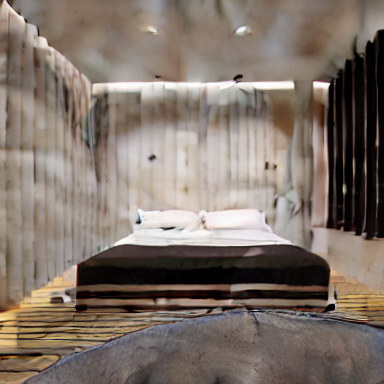

Saved: /workspace/neurodiffusion-studio/outputs/neurodesign_director/test_neurodesign_result.png
VRAM free: 6.09 GB / 21.03 GB


In [6]:
test_prompt = PROMPTS[0]
test_seed = SEEDS[0]

cfg = OptConfig(
    prompt=test_prompt,
    target_rois=TARGET_ROIS,
    suppress_rois=SUPPRESS_ROIS,
    mode=RUN_MODE,
    steps=60,
    lr=0.003,
    seed=test_seed,
    height=HEIGHT,
    width=WIDTH,
    verify_every=VERIFY_EVERY,
)

def progress_cb(step, total, metrics, img_b64):
    if step == 1 or step % 10 == 0 or step == total:
        clear_output(wait=True)
        print(f"Test run: step {step}/{total}")
        print("Prompt:", test_prompt)
        print(json.dumps(metrics, indent=2)[:1200])

result = optimizer.run(cfg, callback=progress_cb)

print("Done.")
print("Initial GT:", result.get("initial_gt_score"))
print("Final GT:", result.get("final_gt_score"))
print("Best step:", result.get("best_step"))

img = b64_to_pil(result["image_b64"], size=HEIGHT)
display(img)

test_path = OUT_DIR / "test_neurodesign_result.png"
img.save(test_path)
print("Saved:", test_path)

clean_gpu()

In [7]:
def safe_float(x):
    try:
        return float(x)
    except Exception:
        return None


def summarize_result(result, prompt, seed, image_path):
    roi = result.get("roi_activations", {}) or {}

    row = {
        "project": PROJECT_NAME,
        "subject": SUBJECT,
        "prompt": prompt,
        "seed": seed,
        "mode": RUN_MODE,
        "height": HEIGHT,
        "width": WIDTH,
        "steps": STEPS,
        "initial_gt_score": safe_float(result.get("initial_gt_score")),
        "final_gt_score": safe_float(result.get("final_gt_score")),
        "best_step": result.get("best_step"),
        "image_path": str(image_path),
    }

    for r in TARGET_ROIS + SUPPRESS_ROIS:
        row[f"roi_{r}"] = safe_float(roi.get(r))

    target_vals = [
        row.get(f"roi_{r}") for r in TARGET_ROIS
        if row.get(f"roi_{r}") is not None
    ]

    suppress_vals = [
        row.get(f"roi_{r}") for r in SUPPRESS_ROIS
        if row.get(f"roi_{r}") is not None
    ]

    target_mean = sum(target_vals) / len(target_vals) if target_vals else 0.0
    suppress_mean = sum(suppress_vals) / len(suppress_vals) if suppress_vals else 0.0

    row["target_mean"] = target_mean
    row["suppress_mean"] = suppress_mean

    # Main design ranking:
    # reward high-level visual activation;
    # penalize FFC and early visual cortex to avoid uncanny faces/noisy hacks.
    row["neurodesign_score"] = target_mean - 0.85 * suppress_mean

    # If the model reports final GT, keep it too.
    if row["final_gt_score"] is not None:
        row["combined_score"] = 0.65 * row["neurodesign_score"] + 0.35 * row["final_gt_score"]
    else:
        row["combined_score"] = row["neurodesign_score"]

    return row


rows = []
failures = []

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

total_runs = len(PROMPTS) * len(SEEDS)
run_idx = 0

for p_idx, prompt in enumerate(PROMPTS):
    for seed in SEEDS:
        run_idx += 1

        name = f"{run_id}_p{p_idx:02d}_seed{seed}_{RUN_MODE}_{HEIGHT}x{WIDTH}"
        image_path = OUT_DIR / f"{name}.png"
        json_path = OUT_DIR / f"{name}.json"

        print("=" * 100)
        print(f"Run {run_idx}/{total_runs}")
        print("Seed:", seed)
        print("Prompt:", prompt)
        print("=" * 100)

        try:
            clean_gpu()

            cfg = OptConfig(
                prompt=prompt,
                target_rois=TARGET_ROIS,
                suppress_rois=SUPPRESS_ROIS,
                mode=RUN_MODE,
                steps=STEPS,
                lr=0.003,
                seed=seed,
                height=HEIGHT,
                width=WIDTH,
                verify_every=VERIFY_EVERY,
            )

            def cb(step, total, metrics, img_b64):
                if step == 1 or step % 20 == 0 or step == total:
                    clear_output(wait=True)
                    print(f"Run {run_idx}/{total_runs}: step {step}/{total}")
                    print("Prompt:", prompt[:160])
                    print("Seed:", seed)
                    print(json.dumps(metrics, indent=2)[:1500])

            result = optimizer.run(cfg, callback=cb)

            img = b64_to_pil(result["image_b64"], size=HEIGHT)
            img.save(image_path)

            with open(json_path, "w") as f:
                json.dump(result, f, indent=2, default=str)

            row = summarize_result(result, prompt, seed, image_path)
            rows.append(row)

            df_live = pd.DataFrame(rows).sort_values("combined_score", ascending=False)
            display(df_live[
                [
                    "combined_score",
                    "neurodesign_score",
                    "final_gt_score",
                    "target_mean",
                    "suppress_mean",
                    "seed",
                    "prompt",
                    "image_path",
                ]
            ].head(10))

        except torch.cuda.OutOfMemoryError as e:
            print("CUDA OOM on run:", run_idx)
            failures.append({
                "prompt": prompt,
                "seed": seed,
                "error": "CUDA OOM",
            })
            clean_gpu()

        except Exception as e:
            print("Failed on run:", run_idx)
            traceback.print_exc()
            failures.append({
                "prompt": prompt,
                "seed": seed,
                "error": repr(e),
            })
            clean_gpu()

df = pd.DataFrame(rows)

csv_path = OUT_DIR / f"{run_id}_neurodesign_results.csv"
df.to_csv(csv_path, index=False)

fail_path = OUT_DIR / f"{run_id}_failures.json"
with open(fail_path, "w") as f:
    json.dump(failures, f, indent=2)

ranked = df.sort_values("combined_score", ascending=False).reset_index(drop=True)

print("Saved CSV:", csv_path)
print("Saved failures:", fail_path)

ranked.head(10)

Run 30/30: step 120/120
Prompt: premium focus-enhancing environment, dynamic architectural lighting, clean futuristic interior, cinematic product design, no humans
Seed: 777
{
  "step": 120,
  "total_steps": 120,
  "loss": -2.812764883041382,
  "brain": 2.886697292327881,
  "suppress": 0.22709231078624725,
  "latent_reg": 0.11609774082899094,
  "coherence": 1.0,
  "source": "BRAIN_MODEL_DIFFERENTIABLE",
  "mode": "latent",
  "gt_pipeline_score": 2.854284854978323,
  "gt_source": "CLIP_DINOV2_FMRI",
  "roi_activations": {
    "V1": -0.7093161344528198,
    "V2": -0.398123562335968,
    "V3": -0.13708409667015076,
    "V4": 1.1517951488494873,
    "V8": 0.6916615962982178,
    "LO1": 1.0476348400115967,
    "LO2": 2.6535274982452393,
    "LO3": 1.693216323852539,
    "FFC": 2.0263257026672363,
    "PIT": 2.1512951850891113,
    "VVC": 2.9129199981689453,
    "MT": 1.9124810695648193,
    "MST": 0.6772528290748596,
    "V3A": 0.5377873182296753,
    "PPA": 0.28501734137535095,
    "OPA": 

,combined_score,neurodesign_score,final_gt_score,target_mean,suppress_mean,seed,prompt,image_path
14,3.179333,3.161615,3.212237,3.239849,0.092040,777,"minimal calming neuro-wellness product, soft f...",/workspace/neurodiffusion-studio/outputs/neuro...
5,3.170569,3.138300,3.230496,3.280785,0.167629,777,"premium sleep pod design, smooth organic surfa...",/workspace/neurodiffusion-studio/outputs/neuro...
21,3.116046,3.063678,3.213300,3.294913,0.272041,42,"stimulating abstract design system, luminous g...",/workspace/neurodiffusion-studio/outputs/neuro...
26,3.024647,3.000864,3.068815,3.105879,0.123547,777,"luxury neurotechnology product design, sculptu...",/workspace/neurodiffusion-studio/outputs/neuro...
27,3.008409,2.959265,3.099675,3.176262,0.255291,42,"premium focus-enhancing environment, dynamic a...",/workspace/neurodiffusion-studio/outputs/neuro...
11,2.996671,2.943699,3.095048,3.177602,0.275180,777,"luxury wellness interior for deep sleep, smoot...",/workspace/neurodiffusion-studio/outputs/neuro...
3,2.975697,2.914257,3.089798,3.185547,0.319165,42,"premium sleep pod design, smooth organic surfa...",/workspace/neurodiffusion-studio/outputs/neuro...
20,2.967668,2.925450,3.046071,3.111864,0.219310,777,"high-end cognitive performance workspace, clea...",/workspace/neurodiffusion-studio/outputs/neuro...
7,2.963052,2.928270,3.027646,3.081851,0.180684,123,"calming bedroom technology concept, sculptural...",/workspace/neurodiffusion-studio/outputs/neuro...
10,2.962156,2.923578,3.033800,3.093921,0.200403,123,"luxury wellness interior for deep sleep, smoot...",/workspace/neurodiffusion-studio/outputs/neuro...


Saved CSV: /workspace/neurodiffusion-studio/outputs/neurodesign_director/20260508_012222_neurodesign_results.csv
Saved failures: /workspace/neurodiffusion-studio/outputs/neurodesign_director/20260508_012222_failures.json


,project,subject,prompt,seed,mode,height,width,steps,initial_gt_score,final_gt_score,...,image_path,roi_VVC,roi_FFC,roi_V1,roi_V2,roi_V3,target_mean,suppress_mean,neurodesign_score,combined_score
0,NeuroDesign Director — Sleek Stimulating Visua...,sub02,"minimal calming neuro-wellness product, soft f...",777,latent,384,384,120,0.957922,3.212237,...,/workspace/neurodiffusion-studio/outputs/neuro...,3.239849,2.147200,-0.874976,-0.546042,-0.358023,3.239849,0.092040,3.161615,3.179333
1,NeuroDesign Director — Sleek Stimulating Visua...,sub02,"premium sleep pod design, smooth organic surfa...",777,latent,384,384,120,-0.293707,3.230496,...,/workspace/neurodiffusion-studio/outputs/neuro...,3.280785,2.201052,-0.840302,-0.497647,-0.192587,3.280785,0.167629,3.138300,3.170569
2,NeuroDesign Director — Sleek Stimulating Visua...,sub02,"stimulating abstract design system, luminous g...",42,latent,384,384,120,-0.117210,3.213300,...,/workspace/neurodiffusion-studio/outputs/neuro...,3.294913,2.316160,-0.699003,-0.416463,-0.112529,3.294913,0.272041,3.063678,3.116046
3,NeuroDesign Director — Sleek Stimulating Visua...,sub02,"luxury neurotechnology product design, sculptu...",777,latent,384,384,120,-0.404653,3.068815,...,/workspace/neurodiffusion-studio/outputs/neuro...,3.105879,2.089877,-0.731081,-0.515754,-0.348855,3.105879,0.123547,3.000864,3.024647
4,NeuroDesign Director — Sleek Stimulating Visua...,sub02,"premium focus-enhancing environment, dynamic a...",42,latent,384,384,120,-0.118883,3.099675,...,/workspace/neurodiffusion-studio/outputs/neuro...,3.176262,2.212445,-0.716759,-0.376821,-0.097703,3.176262,0.255291,2.959265,3.008409
5,NeuroDesign Director — Sleek Stimulating Visua...,sub02,"luxury wellness interior for deep sleep, smoot...",777,latent,384,384,120,-0.132488,3.095048,...,/workspace/neurodiffusion-studio/outputs/neuro...,3.177602,2.215531,-0.663702,-0.366383,-0.084725,3.177602,0.275180,2.943699,2.996671
6,NeuroDesign Director — Sleek Stimulating Visua...,sub02,"premium sleep pod design, smooth organic surfa...",42,latent,384,384,120,-0.088032,3.089798,...,/workspace/neurodiffusion-studio/outputs/neuro...,3.185547,2.262353,-0.617952,-0.317218,-0.050524,3.185547,0.319165,2.914257,2.975697
7,NeuroDesign Director — Sleek Stimulating Visua...,sub02,"high-end cognitive performance workspace, clea...",777,latent,384,384,120,-0.196775,3.046071,...,/workspace/neurodiffusion-studio/outputs/neuro...,3.111864,2.130614,-0.723664,-0.384029,-0.145680,3.111864,0.219310,2.925450,2.967668
8,NeuroDesign Director — Sleek Stimulating Visua...,sub02,"calming bedroom technology concept, sculptural...",123,latent,384,384,120,-0.237940,3.027646,...,/workspace/neurodiffusion-studio/outputs/neuro...,3.081851,2.097915,-0.715771,-0.446785,-0.212624,3.081851,0.180684,2.928270,2.963052
9,NeuroDesign Director — Sleek Stimulating Visua...,sub02,"luxury wellness interior for deep sleep, smoot...",123,latent,384,384,120,-0.218715,3.033800,...,/workspace/neurodiffusion-studio/outputs/neuro...,3.093921,2.144861,-0.751593,-0.406956,-0.184698,3.093921,0.200403,2.923578,2.962156


Saved contact sheet: /workspace/neurodiffusion-studio/outputs/neurodesign_director/20260508_012222_ranked_contact_sheet.png


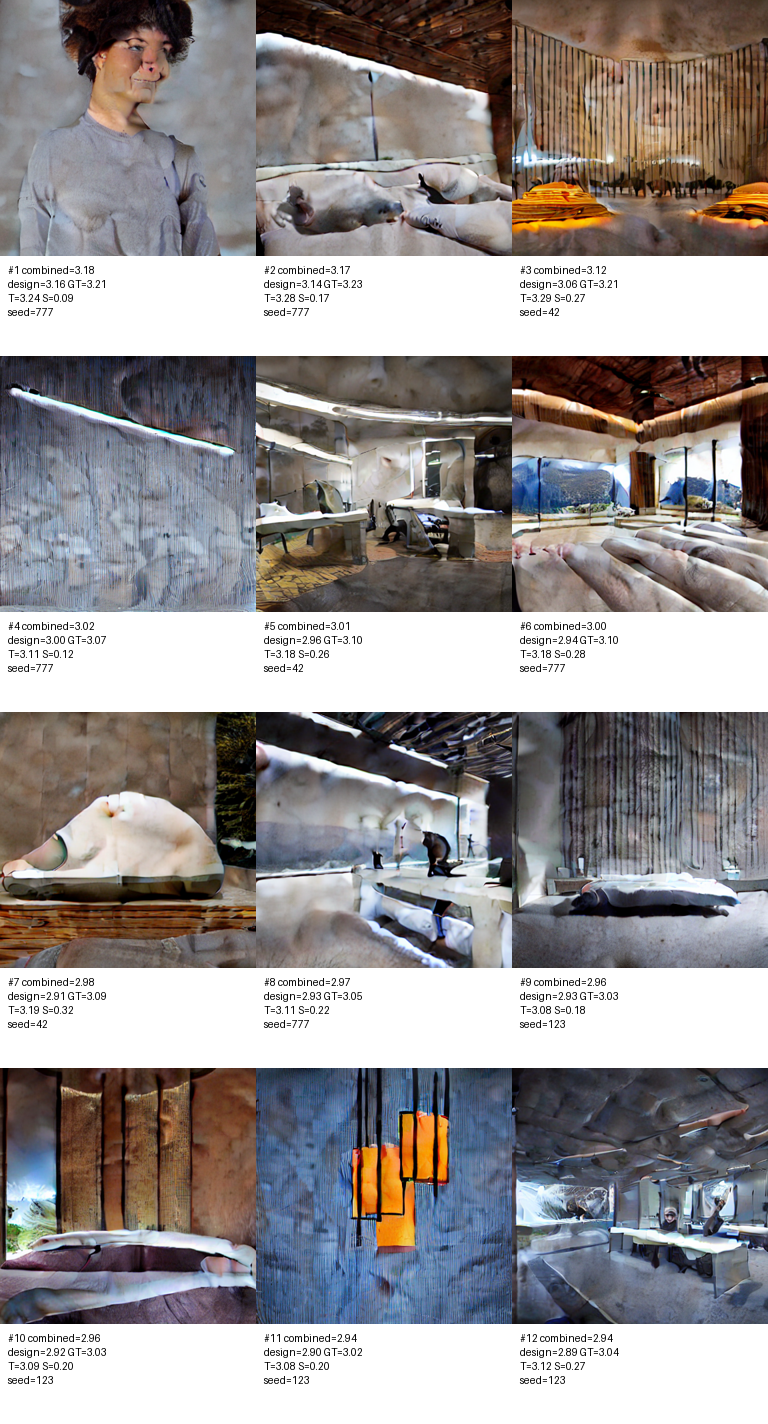

In [8]:
def make_contact_sheet(df, out_path, top_n=12, thumb_size=256):
    d = df.sort_values("combined_score", ascending=False).head(top_n).reset_index(drop=True)

    cols = 3
    rows_n = int((len(d) + cols - 1) / cols)
    label_h = 100

    sheet = Image.new("RGB", (cols * thumb_size, rows_n * (thumb_size + label_h)), "white")
    draw = ImageDraw.Draw(sheet)

    for i, row in d.iterrows():
        x = (i % cols) * thumb_size
        y = (i // cols) * (thumb_size + label_h)

        img = Image.open(row["image_path"]).convert("RGB").resize((thumb_size, thumb_size))
        sheet.paste(img, (x, y))

        label = (
            f"#{i+1} combined={row['combined_score']:.2f}\n"
            f"design={row['neurodesign_score']:.2f} GT={row['final_gt_score']:.2f}\n"
            f"T={row['target_mean']:.2f} S={row['suppress_mean']:.2f}\n"
            f"seed={row['seed']}"
        )

        draw.text((x + 8, y + thumb_size + 8), label, fill=(0, 0, 0))

    sheet.save(out_path)
    return sheet


contact_path = OUT_DIR / f"{run_id}_ranked_contact_sheet.png"
sheet = make_contact_sheet(ranked, contact_path, top_n=min(12, len(ranked)), thumb_size=256)

print("Saved contact sheet:", contact_path)
display(sheet)

Winner: /workspace/neurodiffusion-studio/outputs/neurodesign_director/20260508_012222_p04_seed777_latent_384x384.png
Prompt: minimal calming neuro-wellness product, soft fabric texture, gentle light halo, clean background, no face, no body
Combined score: 3.1793326779827478
Neurodesign score: 3.161615014821291
Final GT: 3.21223690956831
Target mean: 3.2398488521575928
Suppress mean: 0.0920398086309433


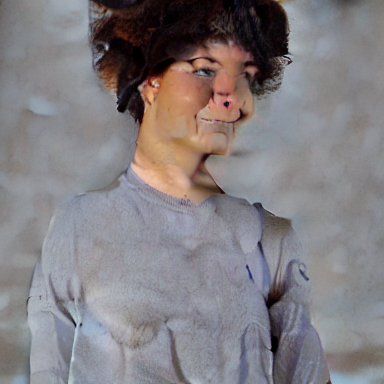

In [9]:
winner_path = ranked.iloc[0]["image_path"]
winner = Image.open(winner_path).convert("RGB")

print("Winner:", winner_path)
print("Prompt:", ranked.iloc[0]["prompt"])
print("Combined score:", ranked.iloc[0]["combined_score"])
print("Neurodesign score:", ranked.iloc[0]["neurodesign_score"])
print("Final GT:", ranked.iloc[0]["final_gt_score"])
print("Target mean:", ranked.iloc[0]["target_mean"])
print("Suppress mean:", ranked.iloc[0]["suppress_mean"])

display(winner)

Winner: /workspace/neurodiffusion-studio/outputs/neurodesign_director/20260508_012222_p04_seed777_latent_384x384.png
Prompt: minimal calming neuro-wellness product, soft fabric texture, gentle light halo, clean background, no face, no body
Combined score: 3.1793326779827478
Neurodesign score: 3.161615014821291
Final GT: 3.21223690956831
Target mean: 3.2398488521575928
Suppress mean: 0.0920398086309433


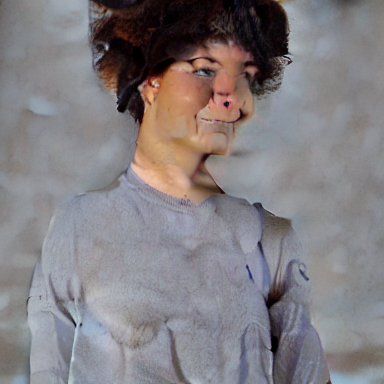

In [10]:
winner_path = ranked.iloc[0]["image_path"]
winner = Image.open(winner_path).convert("RGB")

print("Winner:", winner_path)
print("Prompt:", ranked.iloc[0]["prompt"])
print("Combined score:", ranked.iloc[0]["combined_score"])
print("Neurodesign score:", ranked.iloc[0]["neurodesign_score"])
print("Final GT:", ranked.iloc[0]["final_gt_score"])
print("Target mean:", ranked.iloc[0]["target_mean"])
print("Suppress mean:", ranked.iloc[0]["suppress_mean"])

display(winner)